# Chapter 2: Statistical Learning — Exercises

## Conceptual

### **1.** For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

**(a)** The sample size n is extremely large, and the number of predictors p is small.

- Flexible method can capture strucutre without chasing the noise and large sample size protects us from overfitting.

**(b)** The number of predictors p is extremely large, and the number of observations n is small.

- Inflexible method becasuse of it's rigidity here. Flexible one would have too much freedom relative to the data and will overfit.

**(c)** The relationship between the predictors and response is highly non-linear.

- In such a case it's better to choose flexible method that can better fit the data.

**(d)** The variance of the error terms, i.e. σ² = Var(ϵ), is extremely high.

- Inflexible better, becase a flexible method miskates noise for structure and a rigid method smooths it away.

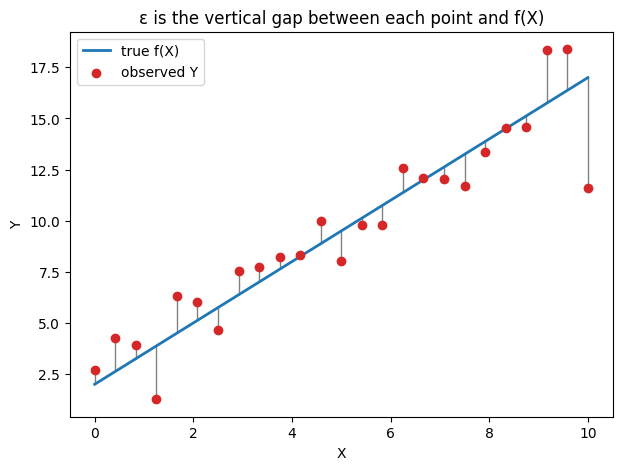

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

x = np.linspace(0, 10, 25)
f = 1.5 * x + 2                     # the true relationship f(X)
eps = rng.normal(0, 2, size=x.size) # the error term: mean 0, variance = sigma^2
y = f + eps                         # observed data: Y = f(X) + eps

plt.figure(figsize=(7, 5))
plt.vlines(x, f, y, color="gray", lw=1)   # each line IS one epsilon
plt.plot(x, f, color="C0", lw=2, label="true f(X)")
plt.scatter(x, y, color="C3", zorder=3, label="observed Y")
plt.xlabel("X"); plt.ylabel("Y"); plt.legend()
plt.title("ε is the vertical gap between each point and f(X)")
plt.show()

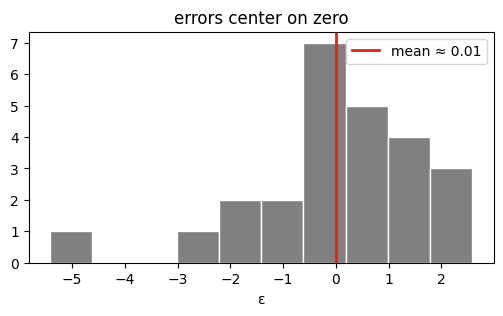

In [2]:
plt.figure(figsize=(6, 3))
plt.hist(eps, bins=10, color="gray", edgecolor="white")
plt.axvline(eps.mean(), color="C3", lw=2, label=f"mean ≈ {eps.mean():.2f}")
plt.xlabel("ε"); plt.legend(); plt.title("errors center on zero")
plt.show()

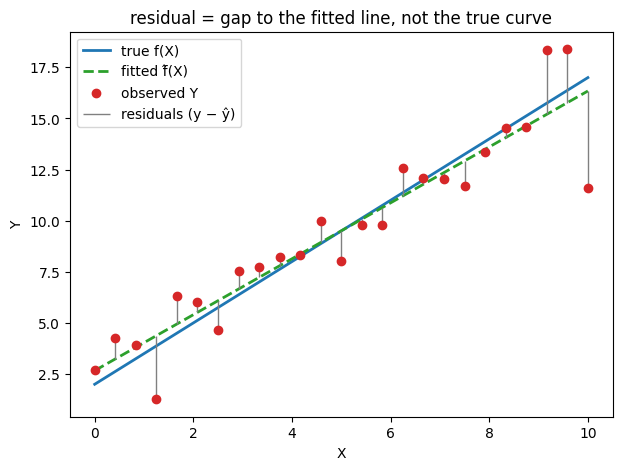

In [3]:
b1, b0 = np.polyfit(x, y, 1)
yhat = b0 + b1 * x

plt.figure(figsize=(7, 5))
plt.plot(x, f, color="C0", lw=2, label="true f(X)")
plt.plot(x, yhat, color="C2", lw=2, ls="--", label="fitted f̂(X)")
plt.scatter(x, y, color="C3", zorder=3, label="observed Y")
plt.vlines(x, yhat, y, color="gray", lw=1, label="residuals (y − ŷ)")
plt.xlabel("X"); plt.ylabel("Y"); plt.legend()
plt.title("residual = gap to the fitted line, not the true curve")
plt.show()

### **2.** Explain whether each scenario is a classification or regression problem, and indicate whether we are most interested in inference or prediction. Finally, provide n and p.

**(a)** We collect a set of data on the top 500 firms in the US. For each firm we record profit, number of employees, industry and the CEO salary. We are interested in understanding which factors affect CEO salary.

- Regression problem and we are interested in inference. n = 500 p = 3

**(b)** We are considering launching a new product and wish to know whether it will be a success or a failure. We collect data on 20 similar products that were previously launched. For each product we have recorded whether it was a success or failure, price charged for the product, marketing budget, competition price, and ten other variables.

- Classification and we are interested in prediction. n = 20, p = 13

**(c)** We are interested in predicting the % change in the USD/Euro exchange rate in relation to the weekly changes in the world stock markets. Hence we collect weekly data for all of 2012. For each week we record the % change in the USD/Euro, the % change in the US market, the % change in the British market, and the % change in the German market.

- Regression and prediction. n = 52, p = 3

### **3.** We now revisit the bias-variance decomposition.

**(a)** Provide a sketch of typical (squared) bias, variance, training error, test error, and Bayes (or irreducible) error curves, on a single plot, as we go from less flexible statistical learning methods towards more flexible approaches. The x-axis should represent the amount of flexibility in the method, and the y-axis should represent the values for each curve. There should be five curves. Make sure to label each one.

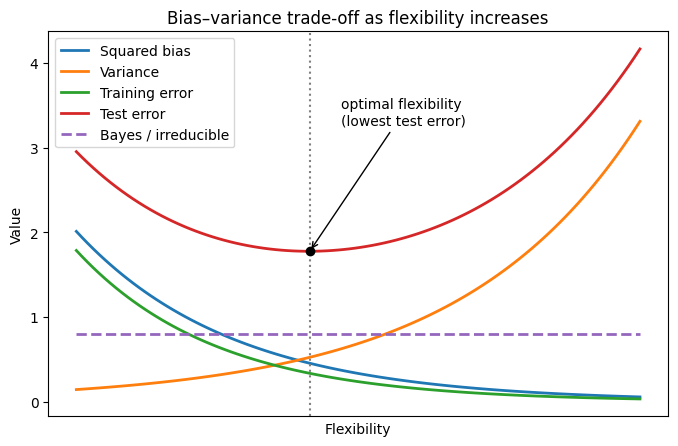

In [ ]:
flex = np.linspace(1, 10, 100)   # x-axis: flexibility (low -> high)

bias2       = 3 * np.exp(-0.4 * flex)        # decreases as flexibility rises
variance    = 0.1 * np.exp(0.35 * flex)      # increases as flexibility rises
irreducible = np.full_like(flex, 0.8)        # flat: the Bayes / irreducible floor
test_error  = bias2 + variance + irreducible # the bias-variance decomposition -> U-shape
train_error = 2.8 * np.exp(-0.45 * flex)     # keeps dropping, can go below irreducible

best = np.argmin(test_error)                 # index where test error is lowest

plt.figure(figsize=(8, 5))
plt.plot(flex, bias2,       label="Squared bias",        lw=2)
plt.plot(flex, variance,    label="Variance",            lw=2)
plt.plot(flex, train_error, label="Training error",      lw=2)
plt.plot(flex, test_error,  label="Test error",          lw=2)
plt.plot(flex, irreducible, label="Bayes / irreducible", lw=2, ls="--")

plt.axvline(flex[best], color="gray", ls=":", lw=1.5)              # best flexibility
plt.scatter(flex[best], test_error[best], color="black", zorder=5) # the minimum point
plt.annotate("optimal flexibility\n(lowest test error)",
             xy=(flex[best], test_error[best]),
             xytext=(flex[best] + 0.5, test_error[best] + 1.5),
             arrowprops=dict(arrowstyle="->"))

plt.xlabel("Flexibility")
plt.ylabel("Value")
plt.title("Bias–variance trade-off as flexibility increases")
plt.legend()
plt.xticks([])          # exact x-values don't matter — only the shapes do
plt.show()

**(b)** Explain why each of the five curves has the shape displayed in part (a).

- **Squared bias — decreasing**. Bias is the error from approximating a complicated real relationship with a model that's too simple. A rigid method (like a straight line) can't match a curvy true f, so it's systematically off — high bias. As you add flexibility, the model can bend to follow the true shape, so this systematic mismatch shrinks. More flexibility → less bias → the curve falls.

- **Variance — increasing**. Variance is how much your fitted f̂ would change if you trained it on a different sample of data. A rigid method barely moves when the data changes — its shape is constrained, so low variance. A flexible method follows the data points closely, so it chases the particular noise in this sample; a different sample would pull it into a different shape. More flexibility → more sensitivity to the sample → the curve rises.

- **Training error — decreasing the whole way**. Training error measures fit on the same data used to build the model. Flexibility always lets you fit that data more tightly — a wiggly enough curve can pass through nearly every training point. So training error just keeps dropping. The catch: past a point it's dropping because the model is memorizing noise, not signal, which is why training error keeps falling even where test error is climbing — and why it can sink below the irreducible line. It's an over-optimistic measure of true performance.

- **Test error — U-shaped**. This is the key one, and its shape isn't independent — it's forced by the other curves. **Test error = bias² + variance + irreducible**. On the left, bias dominates (model too rigid), so test error is high. On the right, variance dominates (model too wiggly, overfitting), so test error climbs again. In the middle the two are balanced, giving the minimum. The U is literally the sum of a falling curve (bias²) and a rising curve (variance) sitting on a flat floor.

- **Bayes / irreducible error — flat**. This is Var(ε), the noise in Y that no model can explain because it doesn't come from X at all. Since it has nothing to do with your choice of method, changing flexibility doesn't touch it — so it's a horizontal line. And because test error always contains this term, the irreducible line is the floor the test-error U bottoms out toward but can never cross.

- **Bias and variance pull in opposite directions as flexibility changes, test error is their sum plus a fixed floor, and that tension is exactly why the best model is neither the simplest nor the most flexible — it's the one at the bottom of the U**

### **4.** You will now think of some real-life applications for statistical learning.

**(a)** Describe three real-life applications in which classification might be useful. Describe the response, as well as the predictors. Is the goal of each application inference or prediction? Explain your answer.

1. **Online purchase prediction**: response = bought/didn't buy, predictors = gender, age, time on site etc., goal = prediction becase we want to forcast a new visitor's behavior, not explan the mechanism

2. **Email spam detection**: response = spam/not spam, predictors = words in the email, sender address, presence of links ect., goal = prediction

3. **Medical diagnosis**: response = disease present/absent, predictors = test results, sumptoms, age, blood markers, goal = both depending on framing - prediction if you want a diagnosis, inference if a researcher wants to know which markers signal the disease.

**(b)** Describe three real-life applications in which regression might be useful. Describe the response, as well as the predictors. Is the goal of each application inference or prediction? Explain your answer.

1. **Sales growth from behavioral survey scores**: response = sales growth, predictors = 10 behaviors scores, goal = inference because we want to know which behaviors drive growth and not just predict a number

2. **House price prediction**: response = sale price, predictors = square footage, number of bedrooms, location, age of house, goal = prediction

3. **Predicting a student's exam score**: response = score, predictors = hours studied, attendance, prior grades, sleep, goal = both - inference if school wants to know what actually moves outcomes, prediction if they want to flag at-risk students early.

**(c)** Describe three real-life applications in which cluster analysis might be useful.

1. **Customer segmentation**: A retailer has data on shopping habits — purchase frequency, average spend, product categories — and wants to group customers into segments (e.g. "bargain hunters," "premium buyers," "occasional shoppers") to target marketing. No predefined labels; the clusters emerge from the data.

2. **Grouping genes by expression pattern**: Biologists measure how active thousands of genes are across many samples and cluster genes that behave similarly, which can hint that they share a function or are involved in the same process.

3. **Organizing news articles or documents by topic**: Given a pile of articles and their word frequencies, clustering groups them into themes (sports, politics, tech) without anyone labelling them in advance.

### **5.** What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

Advantages of a flexible approach:
- Can capture complex, non-linear relationships that a rigid method would miss -> lower bias
- When the frue f is complicated and you have lots of data, it fits much better

Disadvantages of a flexible approach:
- Higher variance - it follows the training data closely, so it's prone to overfitting.
- Harder to interpret - A linear model gives you clean coefficients ("each extra year of education adds £X"); a flexible black box doesn't.
- Needs more data to estimate all its extra parameters reliably

When to prefer more flexible
- True realationships is higly non-linear
- You have a large sample size
- You care mainly about prediction accuracy, not understanding the mechanism

When to prefer less flexible
- Small sample size
- High noise / Var(ε)
- You care about inference / interpretability

The advantage and disadvantage are two sides of the bias-variance trade-off — flexibility lowers bias but raises variance, so the right choice depends on which one is hurting you more.

### **6.** Describe the differences between a parametric and a non-parametric statistical learning approach. What are the advantages of a parametric approach to regression or classification (as opposed to a non-parametric approach)? What are its disadvantages?

Non-parametric methods do not make assuptions about functional form of f. That being said they need much more data potins.

Advantages of a parametric approach:
- Needs less data - only estimating a few parameters not the whole shape of f
- Simpler and faster to fit
- Easier to interpret - a linear model gives you clean coefficients you can read off ("Each unit of X₁ adds β₁ to Y)

Disadvantages of a parametric approach:
- The chosen form is usually wrong - the true f rarely matches your assumption exactly, so you get bias. 
- You can try to fix this with more flexible parametric models (more parameters), but then you risk overfitting

### **7.** The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

| Obs. | X1 | X2 | X3 | Y     |
|------|----|----|----|-------|
| 1    | 0  | 3  | 0  | Red   |
| 2    | 2  | 0  | 0  | Red   |
| 3    | 0  | 1  | 3  | Red   |
| 4    | 0  | 1  | 2  | Green |
| 5    | −1 | 0  | 1  | Green |
| 6    | 1  | 1  | 1  | Red   |

### Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.

**(a)** Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

- Obs 1: (0, 3, 0) → √(0² + 3² + 0²) = √9 = 3
- Obs 2: (2, 0, 0) → √(2² + 0² + 0²) = √4 = 2
- Obs 3: √10
- Obs 4: √5
- Obs 5: √2
- Obs 6: √3

**(b)** What is our prediction with K = 1? Why?

- Obs 5 since the distance is the smallest - Green

**(c)** What is our prediction with K = 3? Why?

- Obs 5, 6 and 2 - Red

**(d)** If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

- Small K gives a more flexible fit with a wiggly decision boundary, while large K smooths it toward linear. A highly non-linear true boundary needs that flexibility to be captured accurately, so we want K small.

## Applied

**8.** This exercise relates to the College data set, which can be found in the file `College.csv` on the book website. It contains a number of variables for 777 different universities and colleges in the US. The variables are:

- `Private`: Public/private indicator
- `Apps`: Number of applications received
- `Accept`: Number of applicants accepted
- `Enroll`: Number of new students enrolled
- `Top10perc`: New students from top 10% of high school class
- `Top25perc`: New students from top 25% of high school class
- `F.Undergrad`: Number of full-time undergraduates
- `P.Undergrad`: Number of part-time undergraduates
- `Outstate`: Out-of-state tuition
- `Room.Board`: Room and board costs
- `Books`: Estimated book costs
- `Personal`: Estimated personal spending
- `PhD`: Percent of faculty with Ph.D.s
- `Terminal`: Percent of faculty with terminal degree
- `S.F.Ratio`: Student/faculty ratio
- `perc.alumni`: Percent of alumni who donate
- `Expend`: Instructional expenditure per student
- `Grad.Rate`: Graduation rate

Before reading the data into Python, it can be viewed in Excel or a text editor.

**(a)** Use the `pd.read_csv()` function to read the data into Python. Call the loaded data `college`. Make sure that you have the directory set to the correct location for the data.

In [116]:
import pandas as pd

college = pd.read_csv("College.csv")
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


**(b)** Look at the data used in the notebook by creating and running a new cell with just the code `college` in it. You should notice that the first column is just the name of each university in a column named something like `Unnamed: 0`. We don't really want pandas to treat this as data. However, it may be handy to have these names for later. Try the following commands and similarly look at the resulting data frames:

```python
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')
```

This has used the first column in the file as an index for the data frame. This means that pandas has given each row a name corresponding to the appropriate university. Now you should see that the first data column is `Private`. Note that the names of the colleges appear on the left of the table. We also introduced a new python object above: a dictionary, which is specified by (key, value) pairs. Keep your modified version of the data with the following:

```python
college = college3
```

In [117]:
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')

college = college3
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


**(c)** Use the `describe()` method to produce a numerical summary of the variables in the data set.

In [118]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


**(d)** Use the `pd.plotting.scatter_matrix()` function to produce a scatterplot matrix of the first columns `[Top10perc, Apps, Enroll]`. Recall that you can reference a list `C` of columns of a data frame `A` using `A[C]`.

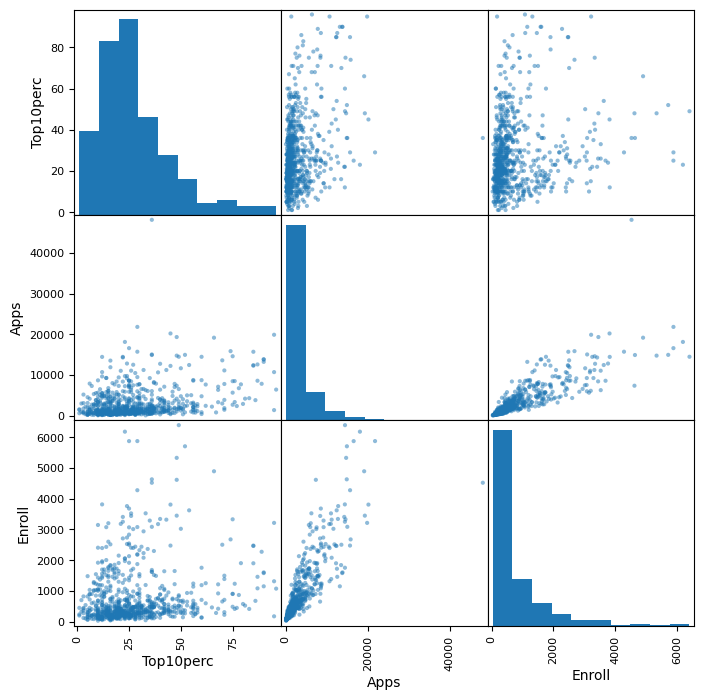

In [124]:
pd.plotting.scatter_matrix(college[["Top10perc", "Apps", "Enroll"]], figsize=(8,8))
plt.show()

**(e)** Use the `boxplot()` method of `college` to produce side-by-side boxplots of `Outstate` versus `Private`.

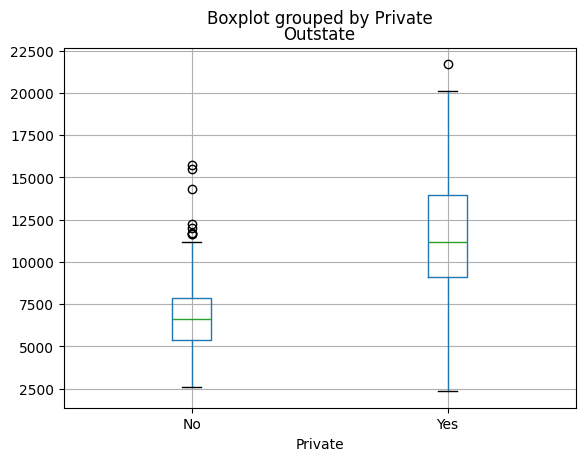

In [125]:
import matplotlib.pyplot as plt

college.boxplot(column="Outstate", by="Private")
plt.show()

**(f)** Create a new qualitative variable, called `Elite`, by binning the `Top10perc` variable into two groups based on whether or not the proportion of students coming from the top 10% of their high school classes exceeds 50%.

```python
college['Elite'] = pd.cut(college['Top10perc'], [0, 0.5, 1], labels=['No', 'Yes'])
```

Use the `value_counts()` method of `college['Elite']` to see how many elite universities there are. Finally, use the `boxplot()` method again to produce side-by-side boxplots of `Outstate` versus `Elite`.

In [127]:
college['Elite'] = pd.cut(college['Top10perc'], [0, 50, 100], labels=['No', 'Yes'])
college['Elite'].value_counts()

Elite
No     699
Yes     78
Name: count, dtype: int64

<Axes: title={'center': 'Outstate'}, xlabel='Elite'>

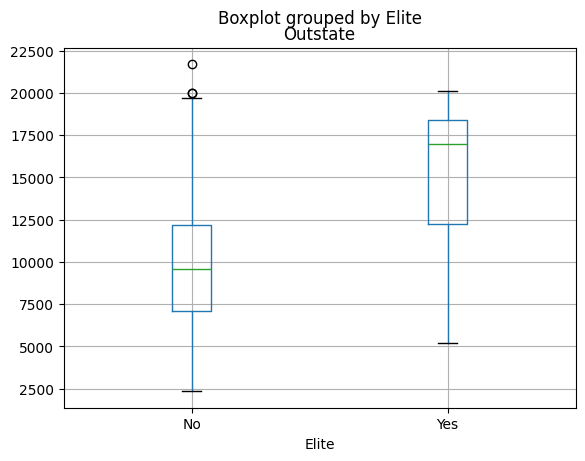

In [128]:
college.boxplot(column="Outstate", by="Elite")

**(g)** Use the `plot.hist()` method of `college` to produce some histograms with differing numbers of bins for a few of the quantitative variables. The command `plt.subplots(2, 2)` may be useful: it will divide the plot window into four regions so that four plots can be made simultaneously. By changing the arguments you can divide the screen up in other combinations.

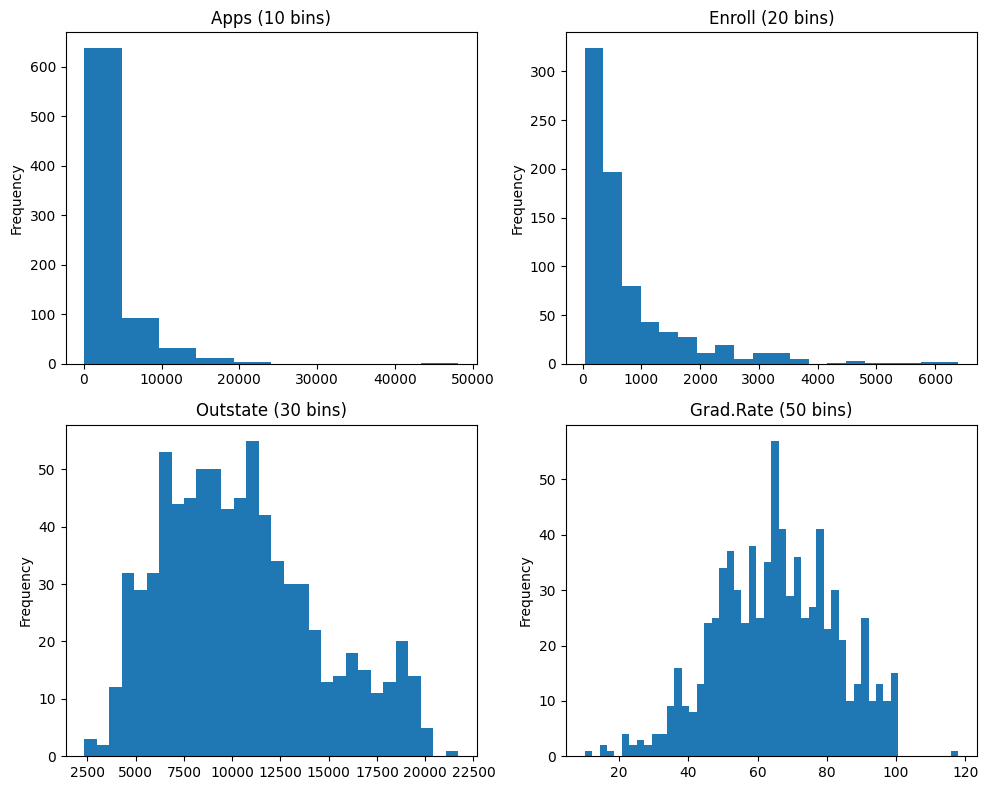

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

college["Apps"].plot.hist(ax=axes[0, 0], bins=10, title="Apps (10 bins)")
college["Enroll"].plot.hist(ax=axes[0, 1], bins=20, title="Enroll (20 bins)")
college["Outstate"].plot.hist(ax=axes[1, 0], bins=30, title="Outstate (30 bins)")
college["Grad.Rate"].plot.hist(ax=axes[1, 1], bins=50, title="Grad.Rate (50 bins)")

plt.tight_layout()
plt.show()

**(h)** Continue exploring the data, and provide a brief summary of what you discover.

In [130]:
college.select_dtypes("number").corr()["Grad.Rate"].sort_values()

S.F.Ratio     -0.306710
Personal      -0.269344
P.Undergrad   -0.257001
F.Undergrad   -0.078773
Enroll        -0.022341
Books          0.001061
Accept         0.067313
Apps           0.146755
Terminal       0.289527
PhD            0.305038
Expend         0.390343
Room.Board     0.424942
Top25perc      0.477281
perc.alumni    0.490898
Top10perc      0.494989
Outstate       0.571290
Grad.Rate      1.000000
Name: Grad.Rate, dtype: float64

**Additional** What drives graduation rate?

In [30]:
import statsmodels.formula.api as smf

# clean the column names so the formula works (statsmodels dislikes dots)
df = college.rename(columns={"Grad.Rate": "GradRate", "S.F.Ratio": "SFRatio",
                             "perc.alumni": "perc_alumni", "Room.Board": "RoomBoard"})

model = smf.ols("GradRate ~ Outstate + Top10perc + SFRatio + perc_alumni + Private",
                data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               GradRate   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     104.2
Date:                Sat, 30 May 2026   Prob (F-statistic):           5.44e-84
Time:                        20:12:31   Log-Likelihood:                -3110.9
No. Observations:                 777   AIC:                             6234.
Df Residuals:                     771   BIC:                             6262.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         31.0360      3.342      9.287      0.000      24.475      37.597
Private[T.Yes]     2.7037      1.389      1.946      0.052      -0.023       5.430
Outstate           0.0014      0.000      7.628      0.000       0.001       0.002
Top10perc          0.2318      0.035      6.638      0.000       0.163       0.300
SFRatio            0.3564      0.152      2.348      0.019       0.058       0.654
perc_alumni        0.2753      0.049      5.637      0.000       0.179       0.371
==============================================================================
Omnibus:                       26.606   Durbin-Watson:                   1.959
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               51.674
Skew:                           0.205   Prob(JB):                     6.01e-12
Kurtosis:                       4.195   Cond. No.                     7.89e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.89e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

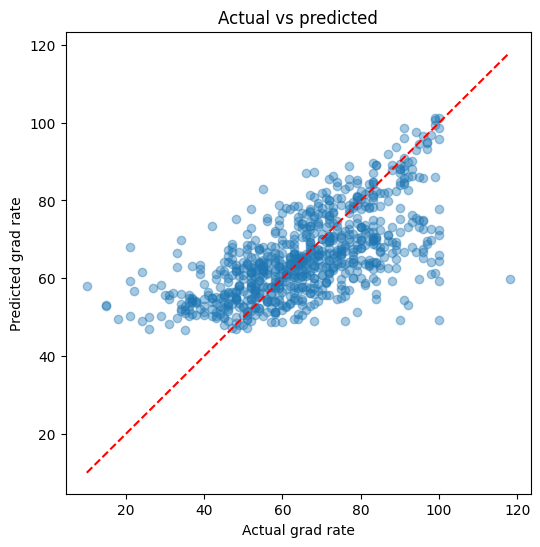

In [31]:
import matplotlib.pyplot as plt

pred = model.fittedvalues          # model's predictions
actual = df["GradRate"]            # true values

plt.figure(figsize=(6, 6))
plt.scatter(actual, pred, alpha=0.4)
lims = [actual.min(), actual.max()]
plt.plot(lims, lims, "r--", lw=1.5)   # the 45-degree perfect-fit line
plt.xlabel("Actual grad rate")
plt.ylabel("Predicted grad rate")
plt.title("Actual vs predicted")
plt.show()

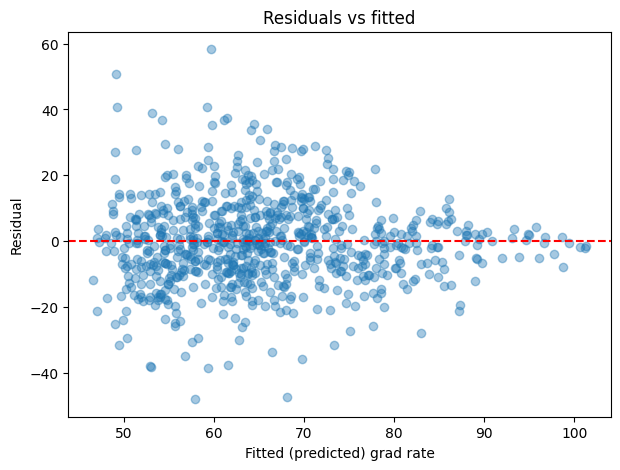

In [32]:
resid = model.resid

plt.figure(figsize=(7, 5))
plt.scatter(pred, resid, alpha=0.4)
plt.axhline(0, color="r", ls="--", lw=1.5)
plt.xlabel("Fitted (predicted) grad rate")
plt.ylabel("Residual")
plt.title("Residuals vs fitted")
plt.show()

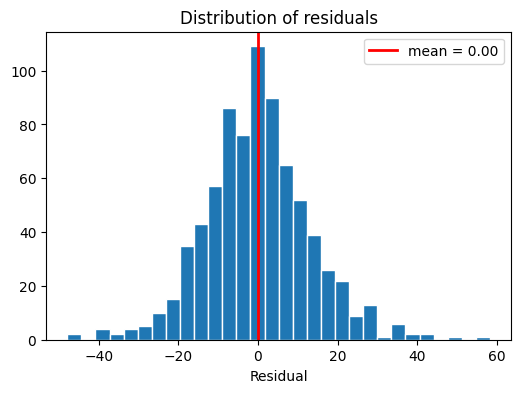

In [131]:
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, edgecolor="white")
plt.axvline(resid.mean(), color="r", lw=2, label=f"mean = {resid.mean():.2f}")
plt.xlabel("Residual")
plt.legend()
plt.title("Distribution of residuals")
plt.show()

### **9.** This exercise involves the `Auto` data set studied in the lab. Make sure that the missing values have been removed from the data.

**(a)** Which of the predictors are quantitative, and which are qualitative?

In [132]:
auto = pd.read_csv('Auto.csv', na_values=['?']).dropna()
auto = auto.reset_index(drop=True)
auto.shape

(392, 9)

In [133]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [134]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


- quantitative are mpg, displacement, horsepower, weight, acceleration, year 
- qualitative are name and origin; cylinders is borderline

**(b)** What is the range of each quantitative predictor? You can answer this using the `min()` and `max()` methods in numpy.

In [135]:
quant = ['mpg','cylinders','displacement','horsepower','weight','acceleration','year']
auto[quant].max() - auto[quant].min()

mpg               37.6
cylinders          5.0
displacement     387.0
horsepower       184.0
weight          3527.0
acceleration      16.8
year              12.0
dtype: float64

**(c)** What is the mean and standard deviation of each quantitative predictor?

In [136]:
auto[quant].mean()

mpg               23.445918
cylinders          5.471939
displacement     194.411990
horsepower       104.469388
weight          2977.584184
acceleration      15.541327
year              75.979592
dtype: float64

In [137]:
auto[quant].std()

mpg               7.805007
cylinders         1.705783
displacement    104.644004
horsepower       38.491160
weight          849.402560
acceleration      2.758864
year              3.683737
dtype: float64

**(d)** Now remove the 10th through 85th observations. What is the range, mean, and standard deviation of each predictor in the subset of the data that remains?

In [138]:
auto_subset = auto.drop(index=range(9, 85))
auto_subset

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
389,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
390,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [139]:
auto_subset[quant].max() - auto_subset[quant].min()

mpg               35.6
cylinders          5.0
displacement     387.0
horsepower       184.0
weight          3348.0
acceleration      16.3
year              12.0
dtype: float64

In [140]:
auto_subset[quant].mean()

mpg               24.404430
cylinders          5.373418
displacement     187.240506
horsepower       100.721519
weight          2935.971519
acceleration      15.726899
year              77.145570
dtype: float64

In [141]:
auto_subset[quant].std()

mpg               7.867283
cylinders         1.654179
displacement     99.678367
horsepower       35.708853
weight          811.300208
acceleration      2.693721
year              3.106217
dtype: float64

**(e)** Using the full data set, investigate the predictors graphically, using scatterplots or other tools of your choice. Create some plots highlighting the relationships among the predictors. Comment on your findings.

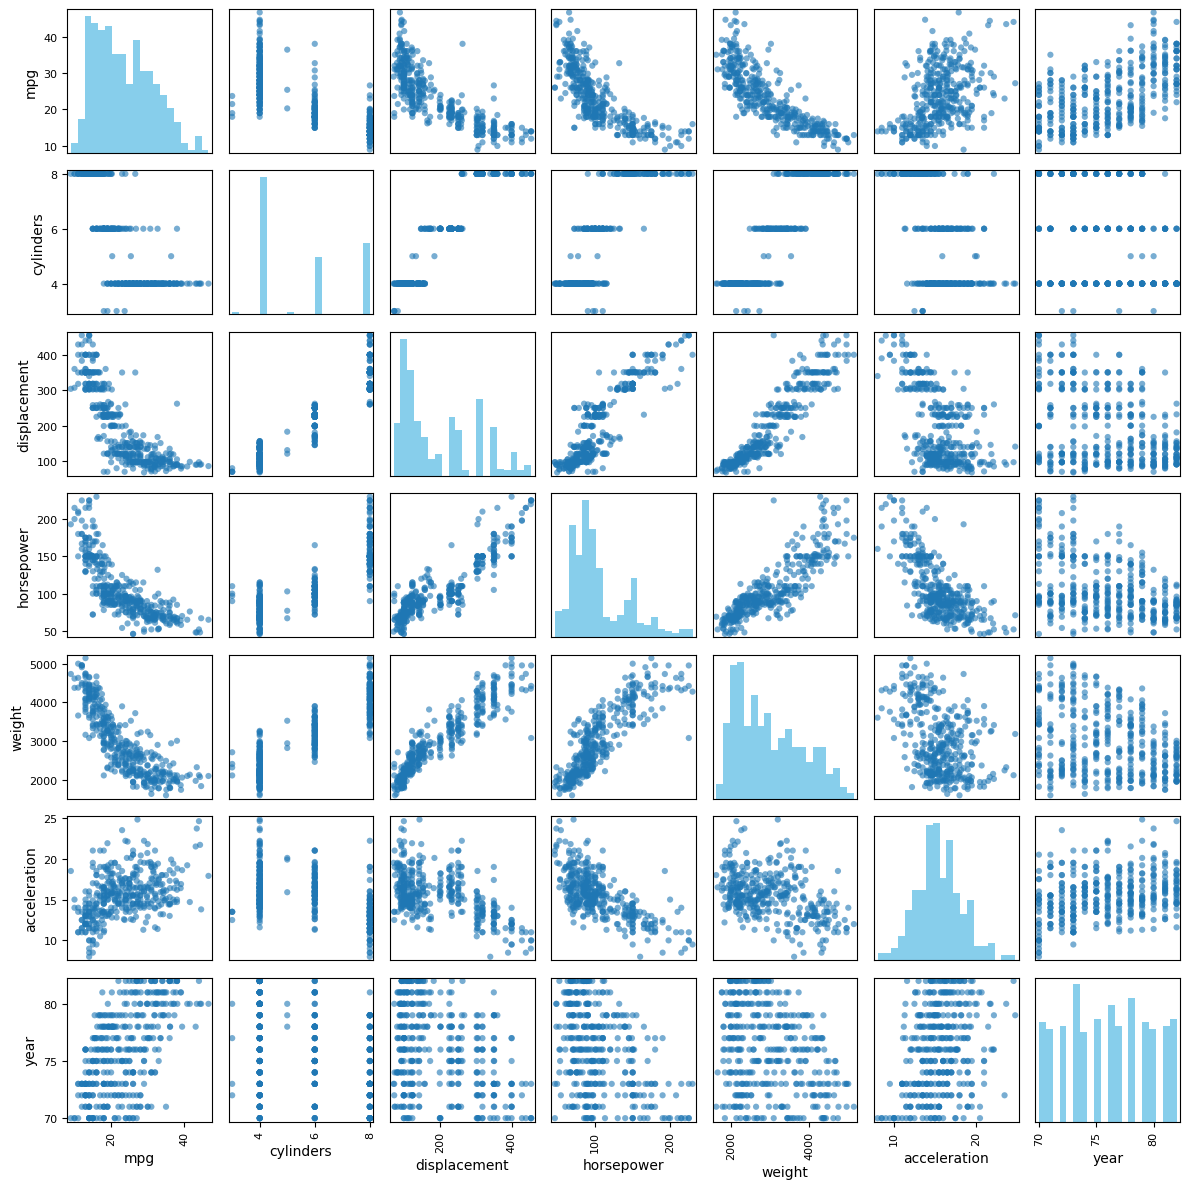

In [150]:
scatter_fig = pd.plotting.scatter_matrix(
    auto[quant],
    figsize=(12, 12),              # make the figure larger
    diagonal='hist',               # use histograms on diagonals for better visibility
    marker='o',                    # clearer marker
    alpha=0.6,                     # some transparency to see overlapping points
    hist_kwds={'bins': 20, 'color': 'skyblue'},    # more bins on histograms
    s=20,                          # bigger marker size
)
plt.tight_layout()
plt.show()

<Axes: >

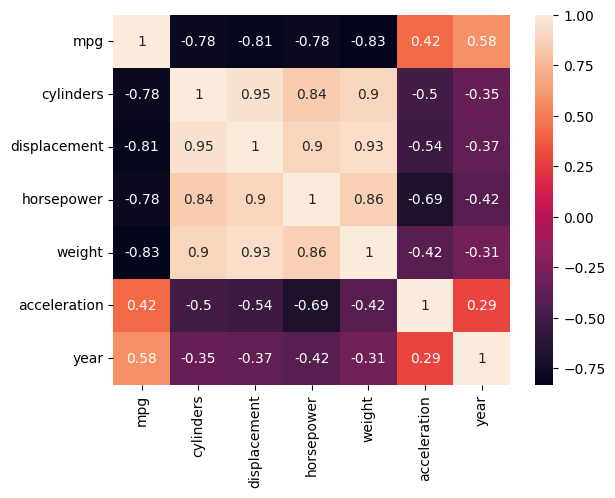

In [151]:
import seaborn as sns

sns.heatmap(auto[quant].corr(), annot=True)

**(f)** Suppose that we wish to predict gas mileage (`mpg`) on the basis of the other variables. Do your plots suggest that any of the other variables might be useful in predicting `mpg`? Justify your answer.

- Strongest relationships with mpg are weight, horespower and displacement. All strongly negative and clearly curved (steep then flattening). Those same 3 variables are also correlated with each other, so they're partly redundant - multicollinearilty. Relationships are non-linear.

### **10.** This exercise involves the Boston housing data set.

**(a)** To begin, load in the Boston data set, which is part of the ISLP library.

In [152]:
boston = pd.read_csv('Boston.csv')
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


**(b)** How many rows are in this data set? How many columns? What do the rows and columns represent?

In [153]:
boston.shape

(506, 14)

#### Each row is a census tract (a small geographic area) in the Boston metropolitan area; this is aggregated area-level data, not individual houses.


- crim — per-capita crime rate by town. Higher = more crime in that tract.
- zn — proportion of residential land zoned for large lots (over 25,000 sq ft). High values mean the 
- area is zoned for spacious, low-density housing.
- indus — proportion of non-retail business acres per town. A proxy for how industrial the area is.
- chas — Charles River dummy variable: 1 if the tract borders the river, 0 otherwise. This is the only categorical (binary) variable in the set.
- nox — nitrogen oxide concentration (parts per 10 million). An air-pollution measure; higher = more polluted, often near industry/highways.
- rm — average number of rooms per dwelling in the tract. A rough measure of house size.
- age — proportion of owner-occupied units built before 1940. High = older housing stock.
- dis — weighted distance to five Boston employment centers. Higher = farther from job hubs (more suburban/outlying).
- rad — index of accessibility to radial highways. Higher = better highway access (it's an index, not a literal distance).
- tax — full-value property tax rate per $10,000. Higher = heavier property taxes.
- ptratio — pupil-to-teacher ratio by town. Higher = more students per teacher (often read as a school-quality proxy).
- lstat — percentage of "lower status" population (the dataset's original term for lower income / less education). Higher = more economically disadvantaged tract.
- medv — median value of owner-occupied homes, in $1000s. This is the response variable — the thing most exercises ask you to predict.

**(c)** Make some pairwise scatterplots of the predictors (columns) in this data set. Describe your findings.

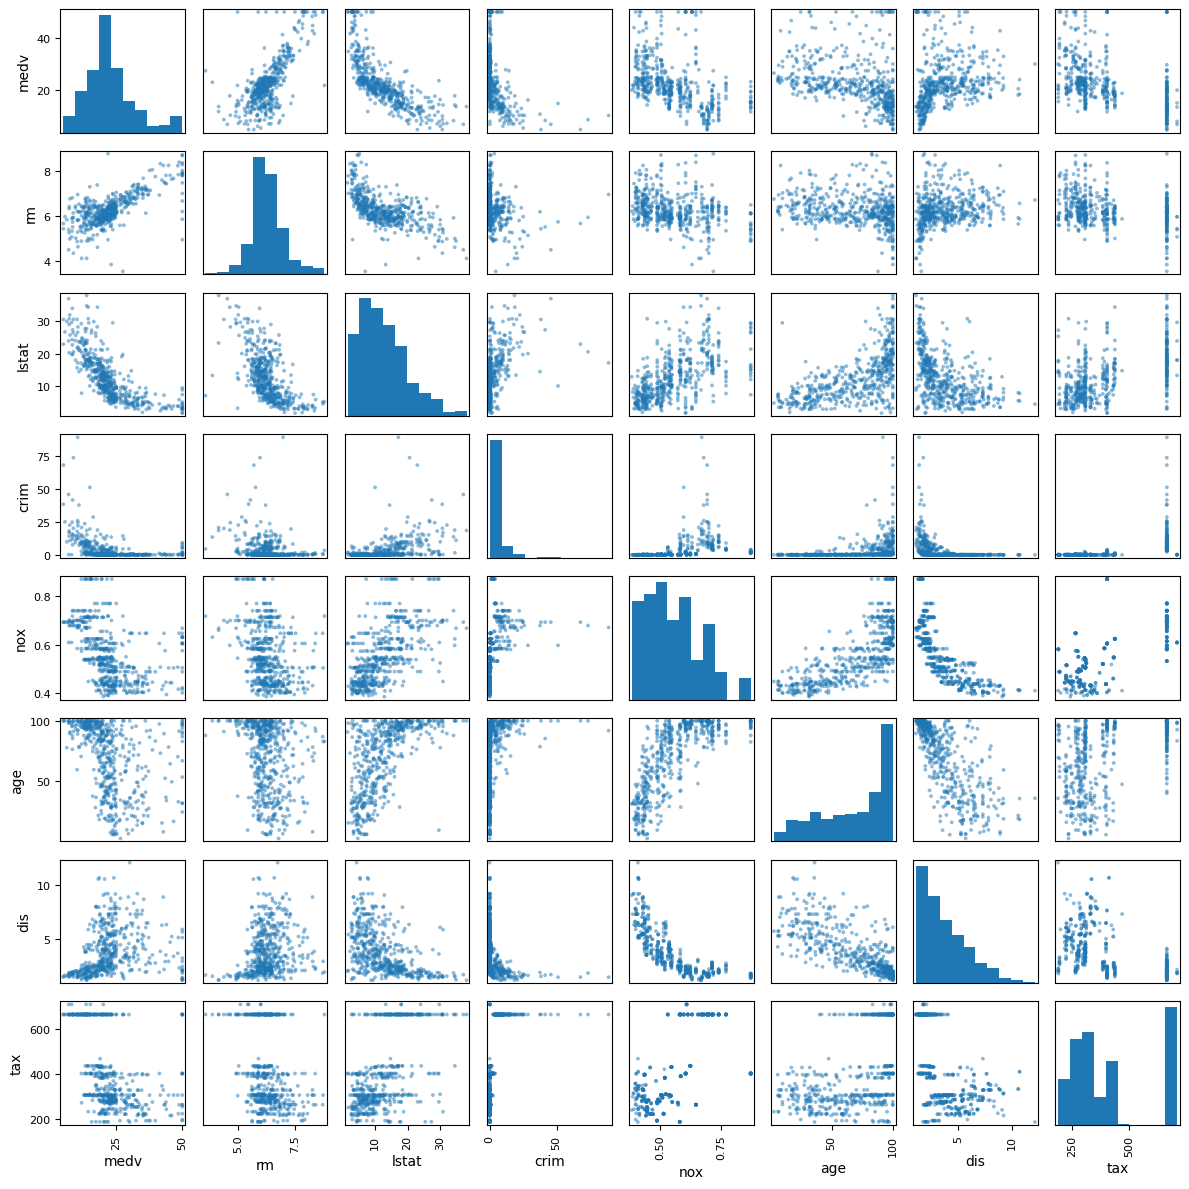

In [155]:
cols = ['medv','rm','lstat','crim','nox','age','dis','tax']
scatter_fig = pd.plotting.scatter_matrix(boston[cols], figsize=(12,12), diagonal='hist', s=30)
plt.tight_layout()
plt.show()

<Axes: >

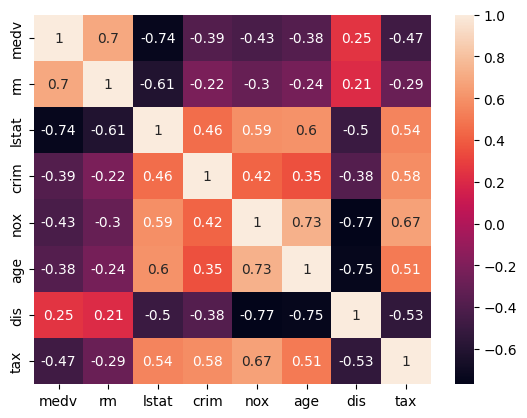

In [156]:
sns.heatmap(boston[cols].corr(), annot=True)

#### What drives home value (medv)

- rm (+0.70) — more rooms → higher value (corr = 0.70)
- lstat (-0.74) — strongest predictor overall; as lower-status % rises, value drops sharply (corr = -0.74)
- tax (-0.47), nox (-0.43), age (-0.38), crim (-0.39) — all negative: higher taxes (corr = -0.47), pollution (corr = -0.43), older housing (corr = -0.38), and crime (corr = -0.39) each track with lower value
- dis (+0.25) — weak positive: tracts farther from employment centers are slightly more valuable (corr = 0.25)

**(d)** Are any of the predictors associated with per capita crime rate? If so, explain the relationship.

In [157]:
boston.corr()['crim'].sort_values()

medv         -0.388305
dis          -0.379670
rm           -0.219247
zn           -0.200469
chas         -0.055892
ptratio       0.289946
age           0.352734
indus         0.406583
Unnamed: 0    0.407407
nox           0.420972
lstat         0.455621
tax           0.582764
rad           0.625505
crim          1.000000
Name: crim, dtype: float64

#### Strongest positive associations

- rad (+0.63) and tax (+0.58) - high crime tracts cluster where highway-accessibility index and property taxes are high
- lstat (+0.46), nox (+0.42), indus (+0.41), age (+0.35) - crime is higher in poorer, more polluted, more industrial and older tracts
- ptratio (+0.29) - higher pupil-tracher ratios

#### Negative

- medv (-0.39) and dis (-0.38) - crime falls as home value rises and as distance from employment centers increases
- rm (-0.22) and zn (-0.2) - weak: less crime where homes are larger and land is zoned for big lots

**(e)** Do any of the suburbs of Boston appear to have particularly high crime rates? Tax rates? Pupil-teacher ratios? Comment on the range of each predictor.

In [158]:
boston[['crim','tax','ptratio']].describe()

,crim,tax,ptratio
count,506.000000,506.000000,506.000000
mean,3.613524,408.237154,18.455534
std,8.601545,168.537116,2.164946
min,0.006320,187.000000,12.600000
25%,0.082045,279.000000,17.400000
50%,0.256510,330.000000,19.050000
75%,3.677083,666.000000,20.200000
max,88.976200,711.000000,22.000000


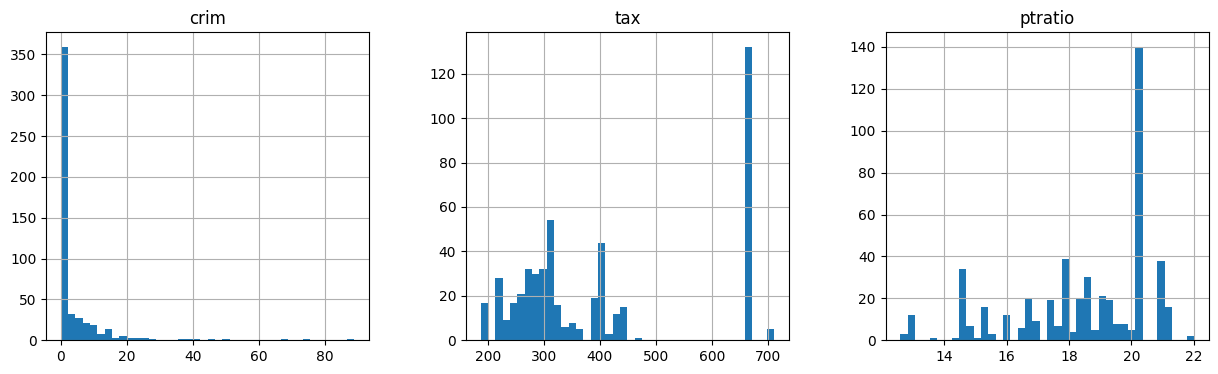

In [160]:
boston[['crim', 'tax', 'ptratio']].hist(bins=40, figsize=(15, 4), layout=(1, 3))
plt.show()

- crim - yes, a few suburbs are extreme. Range 0.006 to 88.98, but mean is only 3.61 and median 0.257. Gap between 75th percentile (3.68) and the max (88.98) tells the whole story: small numer of trackts have crime rates above everyone else. 
- tax - high cluster, not outliers. Range 187 to 711. The 75th percentile and max region are dominated by block of around 130 tracts all sitting at 666. Unlike crime, high tax isin't a handful of outliers - it's a whole separated cluster of central tracts. Bimodal distribution.
- ptratio - high but compressed, no dramatic standouts. Range 12.6 to 22, std 2.16 - the tightest of the three. Spike fo tracts at 20.2. While pupil-tracher ratios are generally high, no suburb is a wild outlier - the spread is narrow.

**(f)** How many of the suburbs in this data set bound the Charles river?

In [161]:
boston['chas'].value_counts()

chas
0    471
1     35
Name: count, dtype: int64

**(g)** What is the median pupil-teacher ratio among the towns in this data set?

In [162]:
boston['ptratio'].median()

np.float64(19.05)

**(h)** Which suburb of Boston has lowest median value of owner-occupied homes? What are the values of the other predictors for that suburb, and how do those values compare to the overall ranges for those predictors? Comment on your findings.

In [163]:
low = boston['medv'].idxmin()
boston.loc[low]

Unnamed: 0    399.0000
crim           38.3518
zn              0.0000
indus          18.1000
chas            0.0000
nox             0.6930
rm              5.4530
age           100.0000
dis             1.4896
rad            24.0000
tax           666.0000
ptratio        20.2000
lstat          30.5900
medv            5.0000
Name: 398, dtype: float64

In [164]:
boston.rank(pct=True).loc[low]

Unnamed: 0    0.788538
crim          0.988142
zn            0.368577
indus         0.757905
chas          0.466403
nox           0.844862
rm            0.077075
age           0.958498
dis           0.057312
rad           0.870553
tax           0.860672
ptratio       0.751976
lstat         0.978261
medv          0.002964
Name: 398, dtype: float64

Lowest-value tract: index 398, medv = 5.0 (0.3rd percentile - essentially the minimum in the dataset). Tract 405 ties at medv = 5.0 with a near-identical profile, so this is really two worst-case tracts, not a lone anomaly.

- crim - 38.35, 99th percentile. One of the very highest-crime tracts.
- lstat - 30.59, 98th percentile. Very large lower-status population - the strongest negative correlate of medv, so this alone explains a lot.
- age - 100, 96th percentile. Every home is pre-1940, the oldest possible housing stock.
- nox / rad / tax - 0.693 (84th), 24 (87th), 666 (86th). High pollution, full highway access, and the high-tax cluster (the 666 block again).
- indus / ptratio - 18.1 (76th), 20.2 (75th). Industrial, crowded schools.
- rm - 5.45, 8th percentile. Few rooms, small homes.
- dis - 1.49, 6th percentile. Very close to employment centers, dense central location.
- zn / chas - 0 (37th) and 0. No large-lot zoning, not on the river.

Finding: the striking thing is the coherence - this isn't low-value for one isolated reason. It's at the bad end of crime, pollution, age, tax, and lstat, and the low end of rooms and distance-from-center, all at once. Every disadvantaged-tract marker converges in the same place: the central-industrial-poor cluster seen throughout parts (c)-(e), now showing up as a single worst-case tract. Because the predictors are intercorrelated, the lowest-value suburb is bad across the board rather than along one dimension.

**(i)** In this data set, how many of the suburbs average more than seven rooms per dwelling? More than eight rooms per dwelling? Comment on the suburbs that average more than eight rooms per dwelling.

In [165]:
(boston['rm'] > 7).sum()  

np.int64(64)

In [166]:
(boston['rm'] > 8).sum()

np.int64(13)

In [168]:
boston[boston['rm'] > 8].describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,232.307692,0.718795,13.615385,7.078462,0.153846,0.539238,8.348538,71.538462,3.430192,7.461538,325.076923,16.361538,4.310000,44.200000
std,60.915768,0.901640,26.298094,5.392767,0.375534,0.092352,0.251261,24.608723,1.883955,5.332532,110.971063,2.410580,1.373566,8.092383
min,98.000000,0.020090,0.000000,2.680000,0.000000,0.416100,8.034000,8.400000,1.801000,2.000000,224.000000,13.000000,2.470000,21.900000
25%,225.000000,0.331470,0.000000,3.970000,0.000000,0.504000,8.247000,70.400000,2.288500,5.000000,264.000000,14.700000,3.320000,41.700000
50%,233.000000,0.520140,0.000000,6.200000,0.000000,0.507000,8.297000,78.300000,2.894400,7.000000,307.000000,17.400000,4.140000,48.300000
75%,258.000000,0.578340,20.000000,6.200000,0.000000,0.605000,8.398000,86.500000,3.651900,8.000000,307.000000,17.400000,5.120000,50.000000
max,365.000000,3.474280,95.000000,19.580000,1.000000,0.718000,8.780000,93.900000,8.906700,24.000000,666.000000,20.200000,7.440000,50.000000


64 suburbs average more than 7 rooms per dwelling; 13 average more than 8.

Comment on the >8-room group (13 tracts):
- crim - low. Mean 0.72 vs 3.61 overall - these large-home tracts are mostly low-crime (though max 3.47 shows one or two exceptions).
- lstat - very low. Well below the overall mean (~12.6) - affluent, low-poverty tracts.
- medv - high. Large homes track with high value, as expected from rm's strong positive correlation with medv.
- age - relatively high (mean 71.5). Many are older, grand homes rather than new construction.
- Finding: the >8-room tracts are a small, distinctive group (13/506) - affluent, low-poverty, low-crime, high-value. They sit at the opposite end of the spectrum from the lowest-medv tract in (h): favorable across most dimensions rather than bad across all. The link isn't perfectly clean though - a few have moderate values - so many rooms is strongly but not perfectly tied to desirability.